## Business Understanding

We want to classify train stations based on how vulnerable they are to meteorological phenomena in Finland. Our goal is to cluster train stations by the amount of delay associated with a weather phenomena. Even though the study is done for educational purposes, the results could be used by VR, for example in prioritizing winter maintenance resources by station. The assumption is that weather causes delays and that some stations are more prone to delays caused or associated different weather phenomena such as rain or freezing temperatures. Only stations where a train has actually stopped are used. The plan is to first extract the data from Kaggle, understand the data, prepare the data, model and evaluate.

### Research questions

- Is there a clear difference between stations in how much weather phenomena increases train delays?
- Are weather-prone stations geographically distinct?

---

## Data Understanding

The data is pulled from Kaggle using Python. The data consists of Finnish railway operational data paired with meteorological observations for delay prediction. The data is filled with records containing a single timetable event `Arrival / Departure` of long-distance VR-trains at stations as well as the weather observation from the nearest weather station at the time of the stop.

[Link to Data (www.kaggle.com)](https://www.kaggle.com/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw)

Period: 2018–2025 | Records: ~48 million | Columns: up to 125 | Sources: Digitraffic + Finnish Meteorological Institute

> **Note:** All exploration below is based on a single month of data. This sample is used only to understand the data's structure and quality and the full date range will be used for modeling.

In [1]:
import kagglehub
import pandas as pd

#download the dataset from Kaggle using the kagglehub library
path = kagglehub.dataset_download("viniborin/finland-integrated-train-weather-dataset-fi-tw")

/Users/blendigraicevci/Documents/dkkog2/dkko-g2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

#import the dataset
file = Path(path) / "matched_data_flat_2025_10.parquet"
metadata_file = Path(path) / "metadata_train_stations.csv"

print(path)

#read the parquet file into a pandas dataframe
df = pd.read_parquet(file)

#List the available columns in the dataset
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"{i:>3}. {col:<45} {dtype}")

/Users/blendigraicevci/.cache/kagglehub/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw/versions/3
  1. trainNumber                                   int64
  2. departureDate                                 str
  3. operatorUICCode                               int64
  4. operatorShortCode                             str
  5. trainType                                     str
  6. trainCategory                                 str
  7. commuterLineID                                float64
  8. runningCurrently                              bool
  9. cancelled                                     bool
 10. version                                       int64
 11. timetableType                                 str
 12. timetableAcceptanceDate                       str
 13. stationName                                   str
 14. stationShortCode                              str
 15. stationUICCode                                int64
 16. countryCode                            

In total we have 123 columns of data in this dataset. We have all the necessary features to correctly associate station delays with weather phenomena. We have different weather data for the time of the stop and also rolling-window aggregates 12h/24h/72h from the time of the stop. We will be using only the instantaneous weather observations for this study. In addition we have necessary information for training such as the delayed time, causes for delay, station data and train data. The next step is to extract and prepare only the necessary data needed to train the model.

In [3]:
df.describe(include='all')

,trainNumber,departureDate,operatorUICCode,operatorShortCode,trainType,trainCategory,commuterLineID,runningCurrently,cancelled,version,...,Precipitation amount (12h mean),Precipitation amount (12h cumulative),Precipitation amount (24h mean),Precipitation amount (24h cumulative),Precipitation amount (72h mean),Precipitation amount (72h cumulative),estimateSource,liveEstimateTime,unknownDelay,unknownTrack
count,537724.000000,537724,537724.000000,537724,537724,537724,0.0,537724,537724,5.377240e+05,...,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,31276,31253,6687,390
unique,NaN,31,NaN,6,8,1,NaN,2,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,20886,2,2
top,NaN,2025-10-17,NaN,vr,IC,Long-distance,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,LIIKE_AUTOMATIC,2025-10-03T18:17:00.000Z,False,True
freq,NaN,19226,NaN,536846,367444,537724,NaN,537540,536382,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28973,6,6418,376
mean,324.708620,NaN,16.441762,NaN,NaN,NaN,NaN,NaN,NaN,2.924115e+11,...,0.085474,1.996041,0.086157,4.043114,0.078725,11.097153,NaN,NaN,NaN,NaN
std,1059.410042,NaN,181.100603,NaN,NaN,NaN,NaN,NaN,NaN,7.827937e+07,...,0.172391,4.027823,0.146912,6.882475,0.103923,14.614362,NaN,NaN,NaN,NaN
min,1.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.922838e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,35.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.923508e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,70.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924087e+11,...,0.000000,0.000000,0.010000,0.400000,0.030000,4.200000,NaN,NaN,NaN,NaN
75%,269.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924697e+11,...,0.090000,2.000000,0.110000,5.400000,0.130000,18.200000,NaN,NaN,NaN,NaN


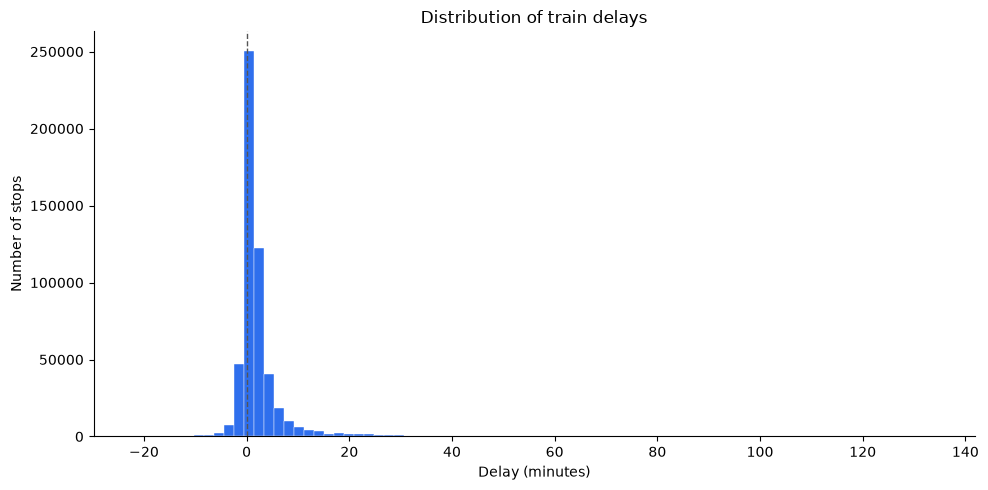

In [4]:
import matplotlib.pyplot as plt

#plot the distribution of train delays, clipped to the 0.1-99.9th percentile to avoid extreme outliers squashing the view
delay = df['differenceInMinutes'].dropna()
lower, upper = delay.quantile([0.001, 0.999])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delay.clip(lower, upper), bins=80, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='#555555', linewidth=1, linestyle='--')
ax.set_title('Distribution of train delays')
ax.set_xlabel('Delay (minutes)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

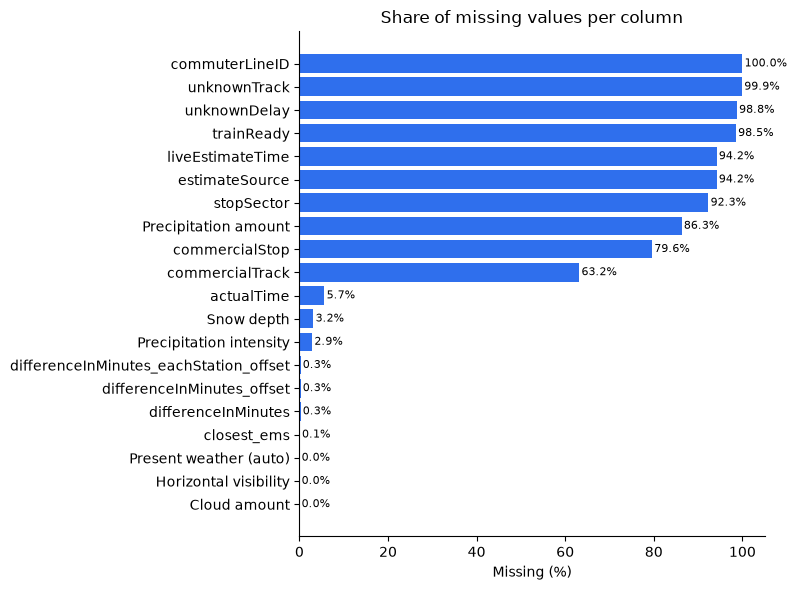

In [5]:
#data quality: share of missing values per column, only columns with at least one missing value
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_pct))))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='#2F6FED')
for y, v in enumerate(missing_pct.values[::-1]):
    ax.text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per column')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

We see the share of missing values per column is unusually high for Precipitation Amount, which is a feature we need for training. We need to make sure that a NaN value means that no precipitation was recorded at the time of the stop. Also features we need such as snow depth and precipitation intensity both have over 4% of missing data.

Next we will plot and analyze the high missing precipitation values.

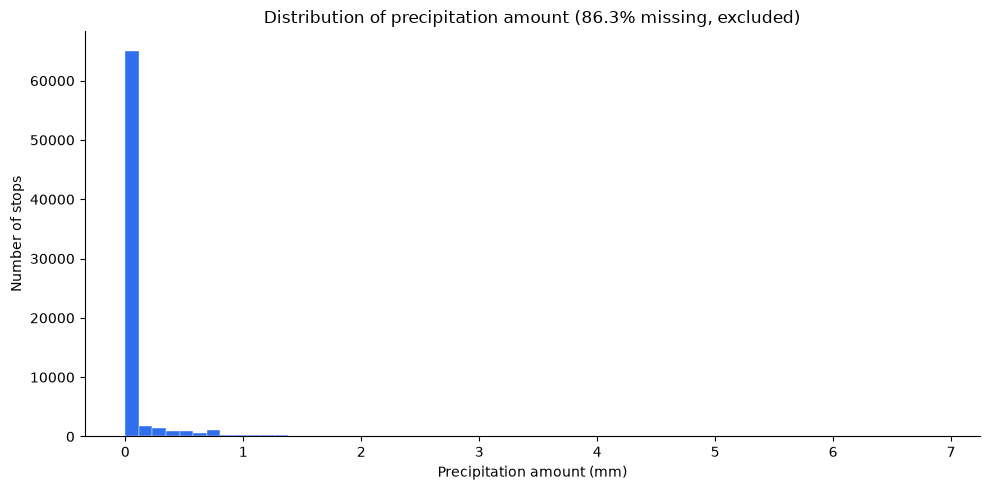

In [6]:
#plot the distribution of precipitation amount 
precip = df['Precipitation amount']
missing_share = precip.isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(precip.dropna(), bins=60, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.set_title(f'Distribution of precipitation amount ({missing_share:.1f}% missing, excluded)')
ax.set_xlabel('Precipitation amount (mm)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
precip = df['Precipitation amount']

print(f"Exactly 0.0: {(precip == 0).sum():,} ({(precip == 0).mean()*100:.1f}%)")
print(f"Non-null and non-zero: {((precip.notna()) & (precip != 0)).sum():,}")
print()
print("Null values:")
print(f"Total null values: {precip.isna().sum():,} ({precip.isna().mean()*100:.1f}%)")
print()
print("Top 10 most common non-null values:")
print(precip.value_counts(dropna=True).head(10))

Exactly 0.0: 61,291 (11.4%)
Non-null and non-zero: 12,451

Null values:
Total null values: 463,982 (86.3%)

Top 10 most common non-null values:
Precipitation amount
0.0    61291
0.1     3775
0.2     1840
0.3     1374
0.4      954
0.5      905
0.7      592
0.6      566
0.8      429
1.0      315
Name: count, dtype: int64


As we can see the missing values do not mean that there was 0 mm of precipitation. They are missing values and the whole column should be deleted because most of the data is missing (86%).

---

## Data Preparation

We will now proceed to select only the necessary columns needed for training and cleaning the data from selected features. 

We decided to use the following features for training:

- `stationShortCode` - the station, used for grouping/clustering
- `trainNumber`, `departureDate` - together identify one train run, needed to follow a train from stop to stop (see *Measuring the delay a station adds* below)
- `scheduledTime` - used to put the stops of a train run in the right order
- `type` - whether the row is the train's `ARRIVAL` or `DEPARTURE` at the station
- `trainStopping` - whether the train actually stopped at the station
- `differenceInMinutes` - how late the train was at this timetable event (used to derive the target variable)
- `causes` - official delay cause codes, used to check whether weather is ever recorded as a cause
- `Air temperature`
- `Wind speed`
- `Relative humidity`
- `Precipitation intensity`
- `Snow depth`
- `Pressure (msl)`
- `Horizontal visibility`
- `Cloud amount`
- `Present weather (auto)` - coded weather phenomenon observed at the time of the stop

We dropped the 12h/24h/72h rolling-window aggregates since we only need the instantaneous observations, `Precipitation amount` (86% missing), `Dew-point temperature`, `Wind direction` and `Gust speed`, and all operational/administrative columns not related to weather or delay such as operator codes, timetable metadata, etc.

These features will provide enough metrics for finding the most weather-prone train stations.

In [8]:
selected_cols = [
    'trainNumber',
    'departureDate',
    'stationShortCode',
    'scheduledTime',
    'type',
    'differenceInMinutes',
    'causes',
    'trainStopping',
    'Air temperature',
    'Wind speed',
    'Relative humidity',
    'Precipitation intensity',
    'Snow depth',
    'Pressure (msl)',
    'Horizontal visibility',
    'Cloud amount',
    'Present weather (auto)',
]

#read only the selected columns directly from the parquet file (columnar format, so this skips loading the rest)
df_selected = pd.read_parquet(file, columns=selected_cols)

#downcast floats to save memory, and turn the repeat-heavy station code into a category
float_cols = df_selected.select_dtypes(include='float64').columns
df_selected[float_cols] = df_selected[float_cols].astype('float32')
df_selected['stationShortCode'] = df_selected['stationShortCode'].astype('category')

After extracting only the columns we need and downcasting, we are able to import the whole 96 months of data to a singular dataframe.

In [9]:
import time

#load every monthly parquet file from 2018-01 to 2025-12, keeping only the selected columns
months = pd.period_range('2018-01', '2025-12', freq='M')
frames = []
failed = []

start = time.time()
for period in months:
    month_file = Path(path) / f"matched_data_flat_{period.strftime('%Y_%m')}.parquet"
    try:
        month_df = pd.read_parquet(month_file, columns=selected_cols)
    except Exception as e:
        failed.append((month_file.name, str(e)))
        continue

    float_cols = month_df.select_dtypes(include='float64').columns
    month_df[float_cols] = month_df[float_cols].astype('float32')
    month_df['stationShortCode'] = month_df['stationShortCode'].astype('category')
    month_df['causes'] = month_df['causes'].astype('category')
    month_df['type'] = month_df['type'].astype('category')
    month_df['departureDate'] = month_df['departureDate'].astype('category')
    frames.append(month_df)

df_all = pd.concat(frames, ignore_index=True)
df_all['stationShortCode'] = df_all['stationShortCode'].astype('category')
df_all['causes'] = df_all['causes'].astype('category')
df_all['type'] = df_all['type'].astype('category')
df_all['departureDate'] = df_all['departureDate'].astype('category')

elapsed = time.time() - start
print(f"Loaded {len(frames)}/{len(months)} months in {elapsed:.1f}s")
if failed:
    print("Failed months:")
    for name, err in failed:
        print(f"  {name}: {err}")

print(f"Rows: {len(df_all):,}")
print(f"Columns: {len(df_all.columns)}")
print(f"Memory: {df_all.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

df_all.describe(include='all')

Loaded 96/96 months in 10.4s
Rows: 47,956,194
Columns: 17
Memory: 3.93 GB


,trainNumber,departureDate,stationShortCode,scheduledTime,type,differenceInMinutes,causes,trainStopping,Air temperature,Wind speed,Relative humidity,Precipitation intensity,Snow depth,Pressure (msl),Horizontal visibility,Cloud amount,Present weather (auto)
count,4.795619e+07,47956194,47956194,47956194,47956194,4.743210e+07,47956194,47956194,4.794273e+07,4.793354e+07,4.794273e+07,4.671124e+07,4.656335e+07,4.794189e+07,4.793717e+07,4.776361e+07,4.793414e+07
unique,NaN,2922,553,8947002,2,NaN,255,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2020-02-07,PSL,2019-02-24T17:38:00.000Z,ARRIVAL,NaN,[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,20940,646075,36,23978097,NaN,47409857,37579076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.582276e+02,NaN,NaN,NaN,NaN,3.736408e+00,NaN,NaN,6.484986e+00,3.802288e+00,7.766042e+01,7.718372e-02,7.682606e+00,1.011625e+03,3.610370e+04,4.898395e+00,1.613681e+01
std,1.151368e+03,NaN,NaN,NaN,NaN,1.350311e+01,NaN,NaN,9.989645e+00,2.140898e+00,1.934145e+01,6.088824e-01,1.542015e+01,1.169856e+01,1.984193e+04,3.422856e+00,2.849657e+01
min,1.000000e+00,NaN,NaN,NaN,NaN,-6.950000e+02,NaN,NaN,-3.920000e+01,0.000000e+00,4.000000e+00,0.000000e+00,-1.000000e+00,9.467000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.800000e+01,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,-3.000000e-01,2.300000e+00,6.500000e+01,0.000000e+00,-1.000000e+00,1.004600e+03,2.000000e+04,0.000000e+00,0.000000e+00
50%,9.400000e+01,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,5.700000e+00,3.500000e+00,8.400000e+01,0.000000e+00,0.000000e+00,1.012300e+03,4.017000e+04,7.000000e+00,0.000000e+00
75%,3.220000e+02,NaN,NaN,NaN,NaN,3.000000e+00,NaN,NaN,1.450000e+01,5.000000e+00,9.300000e+01,0.000000e+00,1.000000e+01,1.019400e+03,5.000000e+04,8.000000e+00,2.200000e+01


The features look mostly natural, but we do notice that the minimum value for `differenceInMinutes` is -695 minutes which is a clear outlier that should be assessed.

In [10]:
delay = (
    df_all["differenceInMinutes"]
    .dropna()
    .sort_values(ascending=True)
    .head(1000)
)

print("First 10 of the first 1000:")
print(delay.head(10))
print()
print("Last 10 of the first 1000:")
print(delay.tail(10))

First 10 of the first 1000:
21725226   -695.0
21725231   -674.0
21725233   -674.0
44761100   -673.0
44761101   -673.0
21725225   -654.0
29112954   -569.0
15977531   -233.0
25168711   -232.0
16025339   -223.0
Name: differenceInMinutes, dtype: float32

Last 10 of the first 1000:
29130151   -96.0
3666275    -95.0
46076269   -95.0
17569491   -95.0
17569492   -95.0
42550748   -95.0
3666276    -95.0
17936797   -95.0
1622375    -95.0
13584843   -95.0
Name: differenceInMinutes, dtype: float32


When ordered by `differenceInMinutes` (ascending) we see a large variation in just the first 1000 rows alone. The first ones are around -600 minutes and the last ones around -95 minutes, meaning that these outliers should not make a big difference as the data is very large (48 million rows).

### Keeping only real stops, and only one row per stop

Before handling missing values we fix two things about *which rows* we look at. Both change what "delay at a station" means, so they have to be done before the station-level aggregation.

**1. Only stops where the train actually stopped (`trainStopping == True`).** Non-stopping records make up a large share of rows at low-traffic station codes, and there is no real delay experienced by passengers there. By keeping only the rows where a train actually stopped, we can more confidently say that this is the delay experienced by passengers.

**2. Only the `DEPARTURE` row of each stop.** Every stop is stored twice in the dataset: once as an `ARRIVAL` event and once as a `DEPARTURE` event (see the counts below - they are exactly equal). In the first version of this notebook we kept both, which meant:

- every stop was counted **twice**, so `stop_count` was doubled and the medians were computed over duplicated data,
- the two rows of one stop carry almost the same delay and the same weather observation, so they are not independent observations - this makes the data look twice as large and twice as convincing as it really is,
- stations at the end of a line only have an `ARRIVAL` row and stations at the start only have a `DEPARTURE` row, so the mix of arrivals and departures was different from station to station.

We keep the `DEPARTURE` row because it includes everything that happened to the train up to the moment it leaves the station - the track leading to the station *and* the time spent at the platform (boarding, frozen doors, switches in the station yard). This is also what the delay metric in the next step needs.

In [11]:
#how many stopping rows are arrivals vs. departures - if the two are ~equal, every stop is in the data twice
stopping = df_all[df_all['trainStopping']]
print("Rows per event type at real stops:")
print(stopping['type'].value_counts())
print()

#keep only stopping DEPARTURE rows -> exactly one row per (train run, station)
rows_before = len(df_all)
df_all = df_all[df_all['trainStopping'] & (df_all['type'] == 'DEPARTURE')].drop(columns=['trainStopping', 'type']).reset_index(drop=True)
df_all['stationShortCode'] = df_all['stationShortCode'].cat.remove_unused_categories()
del stopping
rows_after = len(df_all)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.1f}%)")
print(f"Stations remaining: {df_all['stationShortCode'].nunique()}")

Rows per event type at real stops:
type
ARRIVAL      5188559
DEPARTURE    5188559
Name: count, dtype: int64

Rows before: 47,956,194
Rows after:  5,188,559
Dropped:     42,767,635 (89.2%)
Stations remaining: 500


### Measuring the delay a station adds (instead of the delay a train arrives with)

**The problem.** `differenceInMinutes` tells how late the train is *in total* at that moment. A delay, however, is carried along the whole line: if a train from Helsinki to Oulu gets 10 minutes late because of a frozen switch in Riihimäki, it is also 10 minutes late in Tampere, Seinäjoki, Kokkola and Oulu - even if nothing at all happened at those stations. Using the total delay therefore:

- makes stations **at the end of long lines look vulnerable**, just because delay has piled up on the way there,
- blames each station for weather problems that happened somewhere else, maybe hundreds of kilometres earlier,
- mixes up the question *"which stations cause delay in bad weather?"* with *"which stations are far from where the trains start?"*.

Our research question is about the *stations*, so we need a number that measures only what happens at or just before each station.

**The fix - delay added since the previous stop.** We follow each train run (`departureDate` + `trainNumber`) in timetable order, and for each stop compute

`delay_added = delay when leaving this stop - delay when leaving the previous stop`

This is the delay picked up on the stretch of track leading to the station plus the time lost at the platform. For the first stop of a run (the starting station) there is no previous stop, so the departure delay itself is used - that delay was created at the starting station (late train formation, frozen equipment, etc.).

A useful property: summed over a run, `delay_added` gives back exactly the delay at the last stop, so no delay is lost or counted twice - it is just placed where it was created.

**Two additional decisions:**

- **Negative values are set to 0.** A negative value means the train *caught up* time, for example because the timetable has spare minutes built in. Trains are late more often in winter, so they also catch up more often in winter. In an early test, this made some stations with lots of spare time in the timetable look *less* delayed in bad weather, which hid how vulnerable they really are. Since we are interested in how much delay a station *creates*, we only count delay gained.
- **Extreme values are capped at the 99.9th percentile.** The data contains a few clearly broken values (we saw totals of -695 minutes above), and a difference of two broken values is even more extreme. Since we will now use means (see *Station-level aggregation*), a single broken value could distort a small station, so it is capped.

We compute this *before* dropping rows with missing weather values, because dropping a stop from the middle of a run would make the next stop absorb two stretches of track.

In [12]:
import numpy as np

#put the stops of every train run in timetable order
df_all = df_all.sort_values(['departureDate', 'trainNumber', 'scheduledTime']).reset_index(drop=True)
run = df_all.groupby(['departureDate', 'trainNumber'], observed=True)['differenceInMinutes']

#departure delay at the previous stop of the same run (NaN for the first stop of a run)
previous_delay = run.shift()
is_first_stop = df_all.groupby(['departureDate', 'trainNumber'], observed=True).cumcount() == 0

#delay picked up since the previous stop. At the starting station the whole departure delay was created there
df_all['delay_added'] = np.where(is_first_stop, df_all['differenceInMinutes'], df_all['differenceInMinutes'] - previous_delay).astype('float32')

#example: one train run, to show the difference between total delay and delay added
example_run = df_all.loc[df_all['trainNumber'] == 1, 'departureDate'].iloc[100]
print(f"Example: train 1 on {example_run}")
print(df_all[(df_all['trainNumber'] == 1) & (df_all['departureDate'] == example_run)][['stationShortCode', 'scheduledTime', 'differenceInMinutes', 'delay_added']].to_string(index=False))
print()

#only count delay gained (catching up is not the station's merit in bad weather), and cap broken extreme values
upper_cap = df_all['delay_added'].quantile(0.999)
df_all['delay_added'] = df_all['delay_added'].clip(lower=0, upper=upper_cap)
print(f"delay_added capped to [0, {upper_cap:.0f}] minutes")
print(f"Share of first stops of a run: {is_first_stop.mean() * 100:.1f}%")

#the total delay is not needed any more - from here on delay_added is the target
df_all = df_all.drop(columns=['differenceInMinutes', 'trainNumber', 'departureDate'])
del run, previous_delay, is_first_stop
df_all['delay_added'].describe()

Example: train 1 on 2018-01-09
stationShortCode            scheduledTime  differenceInMinutes  delay_added
             HKI 2018-01-09T05:24:00.000Z                  1.0          1.0
             PSL 2018-01-09T05:30:00.000Z                  1.0          0.0
             TKL 2018-01-09T05:39:00.000Z                  1.0          0.0
              LH 2018-01-09T06:15:00.000Z                  1.0          0.0
              KV 2018-01-09T06:44:00.000Z                  3.0          2.0
              LR 2018-01-09T07:24:00.000Z                  2.0         -1.0
             JTS 2018-01-09T07:38:00.000Z                  3.0          1.0
             IMR 2018-01-09T07:51:00.000Z                  3.0          0.0
             SPL 2018-01-09T08:18:00.000Z                  2.0         -1.0
             PAR 2018-01-09T08:32:00.000Z                  1.0         -1.0
             KTI 2018-01-09T08:54:00.000Z                  0.0         -1.0
             KIT 2018-01-09T09:13:00.000Z                

count    5.111568e+06
mean     1.096867e+00
std      3.533936e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      5.600000e+01
Name: delay_added, dtype: float64

`delay_added` is `NaN` when the train's own delay was not recorded at this stop or the previous one (about 1.5% of the rows). These rows are removed together with the missing weather values below.

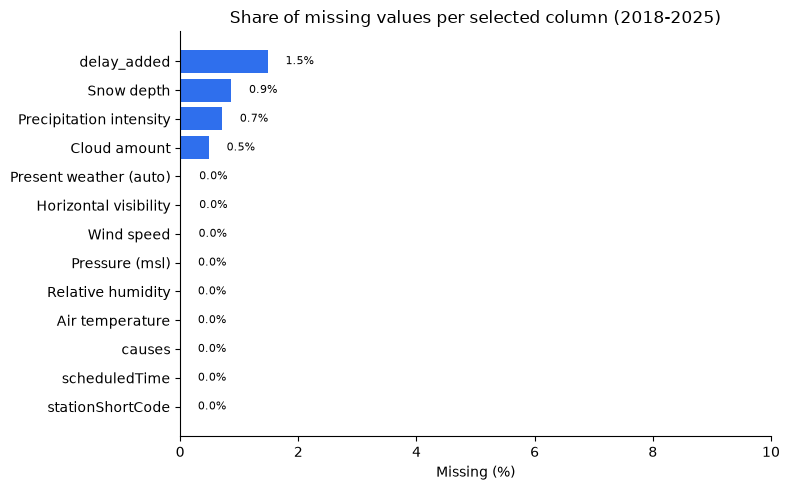

In [13]:
#share of missing values per selected column, across the full 2018-2025 dataset
missing_pct = (df_all.isna().mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(missing_pct.index, missing_pct.values, color='#2F6FED')
for y, v in enumerate(missing_pct.values):
    ax.text(v + 0.3, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, max(10, missing_pct.max() * 1.15))
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per selected column (2018-2025)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
#share of rows that have at least one missing value across the selected columns
rows_with_missing = df_all.isna().any(axis=1).mean() * 100
print(f"Rows with at least one missing value: {rows_with_missing:.1f}%")

Rows with at least one missing value: 2.9%


We decided to delete rows with missing data because predicting or replacing the missing values with the mean for weather features can skew the data. For example, calculating mean for missing snow-depth values could lead to warm months like July having a filled mean value, which does not make sense.


In [15]:
#drop rows with any missing values across the selected columns
rows_before = len(df_all)
df_all = df_all.dropna().reset_index(drop=True)
rows_after = len(df_all)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.1f}%)")

Rows before: 5,188,559
Rows after:  5,039,903
Dropped:     148,656 (2.9%)


### Station-level aggregation

We group all the data by `stationShortCode` to prepare the data for K-means. For every station we calculate:

- the mean of every weather feature (used only to *describe* the clusters afterwards),
- the mean `delay_added` in **good weather**, used as the station's baseline,
- the mean `delay_added` separately in **rain**, **freezing temperatures** and **snow**.

**Why a good-weather baseline?** In the first version, the baseline was the station's median delay over *all* stops. But that number already includes the rainy, freezing and snowy stops, so comparing "delay in snow" against it partly compares snow with itself: a station where trains are often delayed in winter also gets a higher "normal" delay, and its excess shrinks. To measure how much worse things get in bad weather, the comparison has to be against conditions with **no** bad weather. We define good weather as the opposite of all three conditions together:

- no precipitation (`Precipitation intensity == 0`),
- temperature above freezing (`Air temperature >= 0`),
- no snow on the ground (`Snow depth <= 0`; the weather data uses `-1` for "no snow cover").

About 58% of the stops happen in good weather, so the baseline is built from plenty of data.

**Why the mean and not the median any more?** `delay_added` is recorded in whole minutes and is 0 for most stops, so the median is 0 (or 1) for almost every station and condition - it cannot show any difference between stations. The mean still reacts to *how often* and *how much* delay is gained. The mean is sensitive to extreme values, which is why `delay_added` was capped in the previous step, and why conditions with fewer than `MIN_CONDITION_STOPS` stops are left out.

In [16]:
#overall per-station stop count and weather averages (climate columns are used only to describe clusters)
station_features = (
    df_all
    .groupby('stationShortCode', observed=True)
    .agg(
        stop_count=('delay_added', 'size'),
        mean_air_temperature=('Air temperature', 'mean'),
        mean_wind_speed=('Wind speed', 'mean'),
        mean_relative_humidity=('Relative humidity', 'mean'),
        mean_precipitation_intensity=('Precipitation intensity', 'mean'),
        mean_snow_depth=('Snow depth', 'mean'),
        mean_pressure=('Pressure (msl)', 'mean'),
        mean_horizontal_visibility=('Horizontal visibility', 'mean'),
        mean_cloud_amount=('Cloud amount', 'mean'),
    )
    .reset_index()
)

#mean delay added per station, split by weather condition, to capture weather-specific vulnerability.
#a condition built from fewer than MIN_CONDITION_STOPS stops is blanked out -> too small a sample to
#trust, and prone to being skewed by a single extreme delay event
MIN_CONDITION_STOPS = 30

rain_mask = df_all['Precipitation intensity'] > 0
freezing_mask = df_all['Air temperature'] < 0
snow_mask = df_all['Snow depth'] > 0
#good weather = none of the bad-weather conditions -> the baseline the conditions are compared against
good_mask = ~(rain_mask | freezing_mask | snow_mask)

print("Share of stops per condition (rain/freezing/snow can overlap):")
for mask, label in [(good_mask, 'good weather'), (rain_mask, 'rain'), (freezing_mask, 'freezing'), (snow_mask, 'snow')]:
    print(f"  {label:<13} {mask.mean() * 100:5.1f}%   mean delay added {df_all.loc[mask, 'delay_added'].mean():.2f} min")
print()

def delay_by_station(mask, name):
    grouped = df_all[mask].groupby('stationShortCode', observed=True)['delay_added']
    result = grouped.agg(**{name: 'mean', f'{name}_n': 'size'}).reset_index()
    result.loc[result[f'{name}_n'] < MIN_CONDITION_STOPS, name] = np.nan
    return result.drop(columns=f'{name}_n')

condition_masks = [
    (good_mask, 'mean_delay_added_good'),
    (rain_mask, 'mean_delay_added_rain'),
    (freezing_mask, 'mean_delay_added_freezing'),
    (snow_mask, 'mean_delay_added_snow'),
]

for mask, name in condition_masks:
    station_features = station_features.merge(delay_by_station(mask, name), on='stationShortCode', how='left')

print(f"Stations: {len(station_features)}")
station_features.sort_values('stop_count', ascending=False).head(10)

Share of stops per condition (rain/freezing/snow can overlap):
  good weather   58.3%   mean delay added 0.99 min
  rain            7.0%   mean delay added 1.24 min
  freezing       26.6%   mean delay added 1.30 min
  snow           33.4%   mean delay added 1.25 min

Stations: 493


,stationShortCode,stop_count,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,mean_delay_added_good,mean_delay_added_rain,mean_delay_added_freezing,mean_delay_added_snow
316,PSL,312993,8.024956,4.517106,75.809158,0.085087,5.128572,1012.234985,33628.292969,4.397725,0.856978,0.984968,0.982778,0.956551
406,TKL,246739,7.761536,3.651274,76.035652,0.088776,5.444863,1012.228638,32361.988281,4.884712,1.164981,1.490565,1.668695,1.581994
420,TPE,208051,6.583096,4.997983,77.994431,0.074502,6.733916,1011.429749,37756.800781,5.091016,1.973742,2.615943,3.012457,2.847690
31,HKI,158483,8.089185,4.137436,75.450218,0.077425,2.868112,1012.292786,34005.492188,4.439763,1.282097,1.786603,2.356524,2.278396
411,TL,123038,6.700623,3.391115,79.570473,0.068957,5.529308,1011.674927,43338.917969,5.057803,0.576854,0.766723,0.865924,0.848077
373,SK,110724,5.644366,3.132513,79.163933,0.073863,5.936599,1010.922607,42454.253906,4.933854,2.643769,3.250545,3.753556,3.544500
169,KV,101368,6.727693,3.905444,75.308319,0.080942,6.359778,1011.908936,45574.726562,5.116565,1.247905,1.545046,1.666948,1.736990
342,RI,90877,6.663095,2.738422,80.377510,0.084665,7.341671,1012.164124,30938.957031,5.003973,0.600956,0.843702,0.951515,0.882072
35,HL,90123,6.758854,3.510869,77.207275,0.066673,5.860380,1011.552734,33532.687500,4.841084,0.508792,0.602545,0.692065,0.645209
185,LH,88991,7.043692,3.639432,74.980301,0.076189,7.594858,1011.980957,30015.500000,5.101257,0.917405,1.360585,1.543380,1.592850


In [17]:
#check whether the dropped NaN stations are just low-traffic ones or something worth worrying about
condition_cols = ['mean_delay_added_good', 'mean_delay_added_rain', 'mean_delay_added_freezing', 'mean_delay_added_snow']
has_nan = station_features[condition_cols].isna().any(axis=1)

print(f"Stations with at least one NaN condition-delay: {has_nan.sum()} / {len(station_features)}")
print()
print("stop_count for stations WITH NaNs:")
print(station_features.loc[has_nan, 'stop_count'].describe())
print()
print("stop_count for stations WITHOUT NaNs:")
print(station_features.loc[~has_nan, 'stop_count'].describe())
print()
print("Highest-traffic stations that still have a NaN :")
station_features.loc[has_nan].sort_values('stop_count', ascending=False).head(10)

Stations with at least one NaN condition-delay: 274 / 493

stop_count for stations WITH NaNs:
count     274.000000
mean       45.941606
std       106.761915
min         1.000000
25%         2.000000
50%         7.000000
75%        41.500000
max      1183.000000
Name: stop_count, dtype: float64

stop_count for stations WITHOUT NaNs:
count       219.000000
mean      22955.776256
std       36597.982531
min         376.000000
25%        3240.500000
50%       11628.000000
75%       28916.500000
max      312993.000000
Name: stop_count, dtype: float64

Highest-traffic stations that still have a NaN :


,stationShortCode,stop_count,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,mean_delay_added_good,mean_delay_added_rain,mean_delay_added_freezing,mean_delay_added_snow
36,HLS,1183,16.371174,4.055368,63.810650,0.079290,-0.639053,1013.127014,58881.359375,4.124260,1.748644,2.145455,NaN,NaN
66,IKO,698,18.999857,5.718051,74.829514,0.122350,-0.316619,1013.486572,38640.468750,3.071633,2.617785,3.195122,NaN,NaN
421,TPET,385,6.662078,4.835325,77.361038,0.049351,7.311688,1012.175110,38512.230469,4.794805,6.720524,NaN,7.096774,8.416667
225,MJJ,384,0.676563,5.070312,84.406250,0.035677,10.273438,1009.190918,36186.570312,5.190104,2.083333,NaN,2.000000,2.217822
456,VKO,371,7.668464,3.238814,76.126686,0.142049,7.671159,1010.582703,47711.613281,4.978436,6.351695,NaN,2.916667,2.761468
0,AHO,311,-1.709646,3.855305,85.536980,0.063987,6.929260,1001.395203,39029.414062,5.096463,0.763889,NaN,1.127273,1.367647
65,II,304,1.775329,5.616776,80.953949,0.060197,17.460526,1007.315796,33552.386719,4.753290,2.419048,NaN,2.638462,2.584270
296,PKU,301,10.596013,5.548505,84.126244,0.047841,4.156146,1013.712952,33717.011719,3.079734,1.651376,NaN,1.218750,1.328767
380,SLN,292,7.498631,2.406507,74.243149,0.073288,10.743151,1010.111328,39464.726562,4.424657,1.793103,NaN,3.698795,3.235294
104,KE,274,8.228468,4.528467,75.018250,0.092701,5.726277,1014.404419,40413.285156,4.321168,10.137143,NaN,14.333333,17.314285


This justifies our reason to drop all stations with NaN values, as they have too few stops to have any real value on our model.

#### Scaling and dropping small stations with NaN's

After verifying that most of the stations with NaN values are with little traffic. We decided to drop all of them and after that standardize the data and prepare it for K-means.



In [18]:
from sklearn.preprocessing import StandardScaler

#drop any station still carrying a NaN (StandardScaler can't handle them) before scaling
station_features_clean = station_features.dropna().reset_index(drop=True)
print(f"Stations: {len(station_features)} -> {len(station_features_clean)} after dropping remaining NaNs")

#use delay EXCESS relative to each station's own GOOD-WEATHER baseline, instead of the raw condition delays -
#the raw ones are strongly correlated with the baseline (and with each other), so clustering would mostly
#pick up "how delay-prone is this station overall" rather than weather-specific sensitivity
for condition in ['rain', 'freezing', 'snow']:
    station_features_clean[f'excess_delay_{condition}'] = station_features_clean[f'mean_delay_added_{condition}'] - station_features_clean['mean_delay_added_good']

#we cluster ONLY on delay and its weather-specific excess - clustering on the climate averages too would
#group stations by climate zone (cold/snowy north vs mild south) rather than by actual weather sensitivity.
#the climate columns are kept, scaled the same way, and used afterwards only to describe each cluster
cluster_cols = ['mean_delay_added_good', 'excess_delay_rain', 'excess_delay_freezing', 'excess_delay_snow']
climate_cols = [
    'mean_air_temperature',
    'mean_wind_speed',
    'mean_relative_humidity',
    'mean_precipitation_intensity',
    'mean_snow_depth',
    'mean_pressure',
    'mean_horizontal_visibility',
    'mean_cloud_amount',
]
profile_cols = cluster_cols + climate_cols

scaler = StandardScaler()
scaled_features = scaler.fit_transform(station_features_clean[profile_cols])

scaled_df = pd.DataFrame(scaled_features, columns=profile_cols, index=station_features_clean['stationShortCode'])
scaled_df.head(30)

Stations: 493 -> 219 after dropping remaining NaNs


,mean_delay_added_good,excess_delay_rain,excess_delay_freezing,excess_delay_snow,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount
stationShortCode,,,,,,,,,,,,
AHV,-0.030515,1.395461,0.500003,0.399976,1.268859,0.180493,-2.102219,-2.575990,-1.283474,0.340760,-0.335614,-0.484048
ALV,-0.353489,-0.723445,-0.881857,-0.955513,-0.226859,-0.752659,0.857626,-0.067643,0.005154,-0.027391,-2.027696,0.615250
APT,1.373818,0.692249,-0.865681,-0.590502,-0.381323,-0.406373,0.251268,0.607935,0.631104,-0.317046,1.315557,1.184725
DRA,-0.444851,-0.164478,-0.327639,-0.152192,0.920158,3.159113,1.093635,-0.724266,-1.432536,1.153106,-0.231448,-3.016128
ENO,-0.450513,-0.060311,-0.351385,-0.306030,0.211366,-0.046346,-1.142304,0.610260,0.509883,0.481574,0.949985,1.040519
EPZ,-0.925853,-0.537526,-0.475179,-0.430630,0.182342,-0.829228,-0.117053,-0.342690,0.114776,0.089954,-1.910536,0.498633
ERV,0.766164,-0.612869,-0.271453,-0.014743,3.191680,-0.014784,-1.939463,-0.666956,-1.339375,1.139932,-0.400026,-1.092569
HD,-0.080844,-0.008491,-1.313886,-1.247226,-1.327954,1.124822,1.157954,-0.225097,0.298055,-1.268368,-1.495332,-0.219472
HKI,0.352497,0.966473,2.320048,2.340138,1.293409,0.369669,-0.872147,0.572444,-1.233870,1.030492,-0.134032,-1.544666


## Modeling

After succesfully preparing the data we proceed to create the model. We start by finding the optimal amount of clusters (`k`). For this, we start with the elbow-method to try and point out the optimal K-Value.

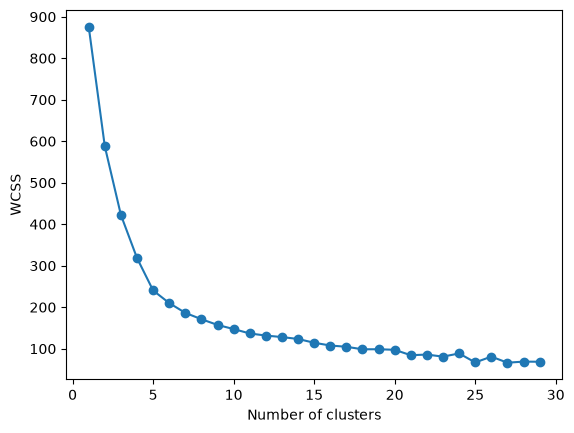

In [28]:
from sklearn.cluster import KMeans

#determine the optimal number of clusters using the elbow method - fit only on cluster_cols,
#the climate columns in scaled_df are for description, not for driving the clustering
wcss = []
for i in range(1,30):
    model = KMeans(init="random", n_clusters=i, random_state=42).fit(scaled_df[cluster_cols])
    wcss.append(model.inertia_)
    
plt.plot(range(1,30), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

We notice that there is not a clear optimal amount of clusters according to the elbow method (immediately clear elbow not visible). Before drawing conclusions we also calculate silhouette scores for each amount of clusters, since they could potentially provide a better/clearer insight.

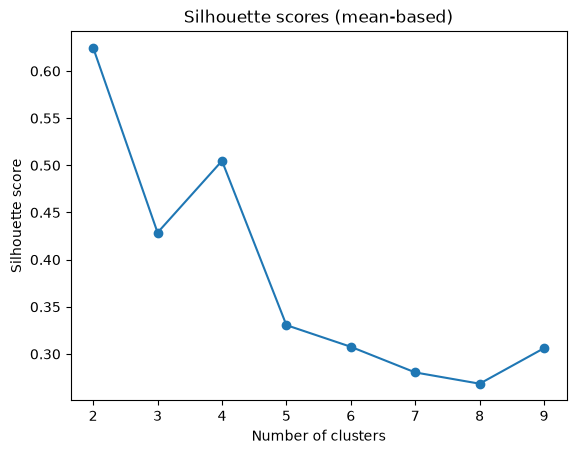

Silhouette scores:
[0.6247332692146301, 0.4286574125289917, 0.5047529935836792, 0.3305666148662567, 0.30760401487350464, 0.28041115403175354, 0.26848167181015015, 0.30616411566734314]


In [20]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 10):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(scaled_df[cluster_cols])
    silhouette_scores.append(silhouette_score(scaled_df[cluster_cols], model.labels_))

def plot_silhouette_scores(scores, range_min = 2, range_max = 10, title = None):
    plt.plot(range(range_min, range_max), scores, 'o-')
    if title: plt.title(title)
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette score')
    plt.show()

plot_silhouette_scores(silhouette_scores, 2, 10, 'Silhouette scores (mean-based)')

print(f'Silhouette scores:\n{silhouette_scores}')

### Robustness check

We also want to check that the result does not depend on one particular way of summarising the delays. The main model uses the **mean** delay added. As an alternative we describe each station by **how often** a train gains a noticeable delay there: the share of stops (%) where at least 3 minutes were added, again in good weather and as an excess in rain, freezing and snow.

(The first version used the 75th percentile here. With `delay_added`, which is in whole minutes and mostly 0, the 75th percentile is the same small integer for most stations, so it can no longer tell stations apart.)

If both descriptions put the same stations in the vulnerable group, the result is not just an artefact of using means.

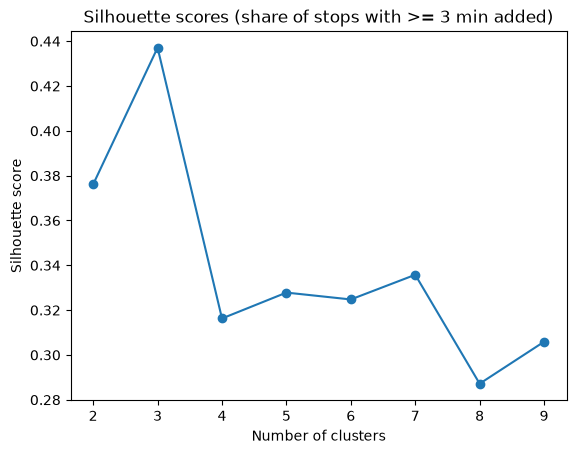

Mean-based silhouette scores:
[0.6247332692146301, 0.4286574125289917, 0.5047529935836792, 0.3305666148662567, 0.30760401487350464, 0.28041115403175354, 0.26848167181015015, 0.30616411566734314]
Share-based silhouette scores:
[0.37612152099609375, 0.43710508942604065, 0.31627845764160156, 0.32782748341560364, 0.324765145778656, 0.3357734978199005, 0.28717240691185, 0.30589792132377625]


In [21]:
#alternative profile: share of stops (%) where at least 3 minutes of delay was added
NOTICEABLE_DELAY = 3
df_all['noticeable_delay'] = (df_all['delay_added'] >= NOTICEABLE_DELAY).astype('float32')

def share_by_station(mask, name):
    grouped = df_all[mask].groupby('stationShortCode', observed=True)['noticeable_delay']
    result = grouped.agg(**{name: 'mean', f'{name}_n': 'size'}).reset_index()
    result.loc[result[f'{name}_n'] < MIN_CONDITION_STOPS, name] = np.nan
    result[name] = result[name] * 100
    return result.drop(columns=f'{name}_n')

#use exactly the same stations as the main model so the two can be compared station by station
share_features = station_features_clean[['stationShortCode']].copy()
for mask, name in condition_masks:
    share_name = name.replace('mean_delay_added', 'share_noticeable')
    share_features = share_features.merge(share_by_station(mask, share_name), on='stationShortCode', how='left')

for condition in ['rain', 'freezing', 'snow']:
    share_features[f'excess_share_{condition}'] = share_features[f'share_noticeable_{condition}'] - share_features['share_noticeable_good']

share_cols = ['share_noticeable_good', 'excess_share_rain', 'excess_share_freezing', 'excess_share_snow']
share_scaled = StandardScaler().fit_transform(share_features[share_cols])

share_silhouette_scores = []
for k in range(2, 10):
    share_model = KMeans(init='random', n_clusters=k, random_state=42)
    share_labels = share_model.fit_predict(share_scaled)
    share_silhouette_scores.append(silhouette_score(share_scaled, share_labels))

plot_silhouette_scores(share_silhouette_scores, 2, 10, f'Silhouette scores (share of stops with >= {NOTICEABLE_DELAY} min added)')

print(f'Mean-based silhouette scores:\n{silhouette_scores}')
print(f'Share-based silhouette scores:\n{share_silhouette_scores}')

# The mean-based model remains the main clustering result; the share-based one is a sensitivity check.
# After fitting the final model we compare the two station by station.

These tests and checks indicate that the optimal amount of clusters `k` for the problem is **2**:

- With the main (mean-based) profile, k=2 has clearly the highest silhouette score (about 0.62; the next best is k=4 with about 0.50).
- The split is **not balanced**: a small group of 18 stations with clearly more weather-specific delay, and 201 stations close to the average. This fits the question - we are looking for the stations that stand out, not for groups of equal size.
- The share-based robustness model is less clear-cut (its best k is 3, k=2 has a silhouette of about 0.38), but the comparison table below shows that **all 18 stations** of the vulnerable mean-based cluster are also in the vulnerable group of the share-based model. The share-based model puts some more stations in that group, so it is a looser version of the same result rather than a different one.

Increasing the amount of clusters from 2 upwards mostly splits the large group into small pieces or isolates single extreme stations, rather than finding more interesting structure. Therefore we pick **k=2** for the final model.

**Note on the change from the first version:** the earlier version (total delay, both arrival and departure rows, all-weather baseline) also ended up with k=2, but with a different set of stations. The results below are not comparable to that version, because the delay is now measured as the delay each station *adds*.

In [32]:
#fit the final model with the chosen k and assign a cluster label back to each station
K = 4
final_model = KMeans(n_clusters=K, init='random', random_state=42).fit(scaled_df[cluster_cols])
#K-means numbers clusters arbitrarily, so relabel them: cluster 0 = highest mean weather excess (the
#weather-vulnerable group). This keeps the colours and text below correct even if the result changes
excess_cols = ['excess_delay_rain', 'excess_delay_freezing', 'excess_delay_snow']
excess_per_label = pd.Series(station_features_clean[excess_cols].mean(axis=1).to_numpy()).groupby(final_model.labels_).mean()
relabel = {old: new for new, old in enumerate(excess_per_label.sort_values(ascending=False).index)}
final_labels = np.array([relabel[label] for label in final_model.labels_])
station_features_clean['cluster'] = final_labels

print(station_features_clean['cluster'].value_counts().sort_index())
print()

#mean of each clustering feature per cluster, to see what distinguishes them
station_features_clean.groupby('cluster')[cluster_cols].mean()


cluster
0      1
1     33
2    174
3     11
Name: count, dtype: int64



,mean_delay_added_good,excess_delay_rain,excess_delay_freezing,excess_delay_snow
cluster,,,,
0,10.252831,1.585008,3.409746,3.175741
1,1.559567,0.637325,0.632692,0.578716
2,0.692591,0.119731,0.094945,0.074930
3,2.069966,-0.553184,-0.448284,-0.477785


In [34]:
#robustness: do the stations of the vulnerable cluster also stand out in the share-based model (k=2)?
share_labels_k2 = KMeans(init='random', n_clusters=K, random_state=42).fit_predict(share_scaled)
share_excess = share_features[['excess_share_rain', 'excess_share_freezing', 'excess_share_snow']].mean(axis=1)
share_vulnerable_label = share_excess.groupby(share_labels_k2).mean().idxmax()

comparison = pd.crosstab(
    station_features_clean['cluster'].map({0: 'mean-based: vulnerable', 1: 'mean-based: other'}),
    np.where(share_labels_k2 == share_vulnerable_label, 'share-based: vulnerable', 'share-based: other'),
)
comparison

col_0,share-based: other,share-based: vulnerable
cluster,,
mean-based: other,17,16
mean-based: vulnerable,0,1


### Cluster vulnerability heatmap

The cluster assignment itself comes only from `median_delay` and the excess-delay columns. The heatmap below also shows the climate columns, used only to describe each cluster afterward - e.g. is the vulnerable cluster also the colder/snowier one, or does it stand out purely on delay behaviour?

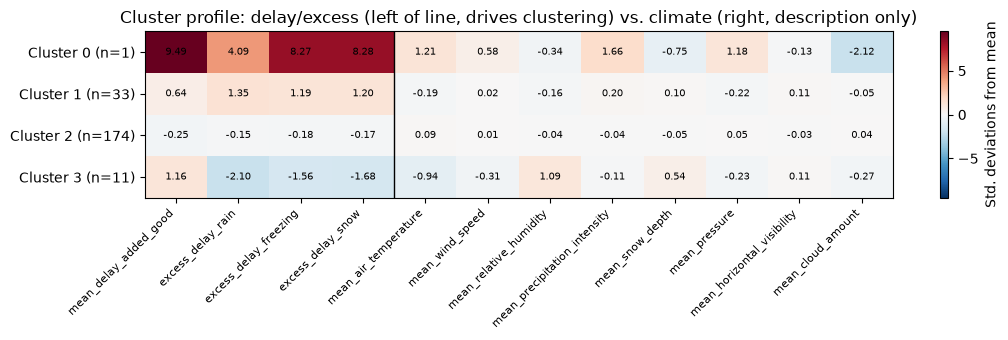

In [33]:
#heatmap of each cluster's mean standardized profile, across both the clustering columns and the
#climate columns (diverging colormap: red = above the overall average, blue = below)
scaled_with_cluster = scaled_df.copy()
scaled_with_cluster['cluster'] = final_labels
cluster_profile = scaled_with_cluster.groupby('cluster')[profile_cols].mean()

fig, ax = plt.subplots(figsize=(11, 3.5))
vmax = cluster_profile.abs().to_numpy().max()
im = ax.imshow(cluster_profile.to_numpy(), aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(profile_cols)))
ax.set_xticklabels(profile_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(cluster_profile)))
ax.set_yticklabels([f'Cluster {i} (n={n})' for i, n in station_features_clean['cluster'].value_counts().sort_index().items()])

#mark the boundary between the clustering columns and the description-only climate columns
ax.axvline(len(cluster_cols) - 0.5, color='black', linewidth=1)

for i in range(cluster_profile.shape[0]):
    for j in range(cluster_profile.shape[1]):
        ax.text(j, i, f'{cluster_profile.to_numpy()[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Cluster profile: delay/excess (left of line, drives clustering) vs. climate (right, description only)')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Std. deviations from mean')
plt.tight_layout()
plt.show()

The heatmap shows the standardized mean profile of each cluster. Cluster 1 (201 stations) is slightly below average on all delay features, indicating less weather-prone stations. Cluster 0 (18 stations) has a higher baseline delay added in good weather (+1.6 std) and an even stronger excess delay during rain (+1.9), freezing temperatures (+2.1) and snow (+2.1). In other words, these stations add some delay in normal conditions, and clearly more when the weather is bad.

Values on the right side of the map tell whether the difference is associated with other climate variables, but they are not used as the main clustering features. Here the two clusters differ much less on climate (all within about ±0.5 std) than on the delay features.

### Map of stations by cluster

Plotting every clustered station on a map of Finland using `folium` (free, OpenStreetMap-based, no API key). Coordinates come from the same source dataset, from a separate `metadata_train_stations.csv` file, joined on `stationShortCode`. Cluster 0 (weather-vulnerable) is red, cluster 1 (near-baseline) is blue.

In [25]:
import folium

#join cluster assignments with station coordinates from the metadata file
metadata = pd.read_csv(metadata_file)
stations_geo = station_features_clean[['stationShortCode', 'cluster']].merge(
    metadata[['stationShortCode', 'stationName', 'latitude', 'longitude']],
    on='stationShortCode',
    how='left',
)

missing_coords = stations_geo['latitude'].isna().sum()
print(f"Stations missing coordinates: {missing_coords} / {len(stations_geo)}")
stations_geo = stations_geo.dropna(subset=['latitude', 'longitude'])

cluster_colors = {0: 'red', 1: 'blue'}

m = folium.Map(location=[64.5, 26.0], zoom_start=5, tiles='OpenStreetMap')

for _, row in stations_geo.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=cluster_colors.get(row['cluster'], 'gray'),
        fill=True,
        fill_color=cluster_colors.get(row['cluster'], 'gray'),
        fill_opacity=0.8,
        popup=f"{row['stationName']} ({row['stationShortCode']}) - cluster {row['cluster']}",
    ).add_to(m)

m

Stations missing coordinates: 0 / 219


### Validation: do the official delay causes agree?

So far the weather conditions and the clusters are based only on *our* interpretation of the weather observations. The dataset also contains an independent source: the official delay cause codes (`causes`) that traffic control records when a train is delayed. We loaded this column at the start but had not used it yet. Using it lets us check our results against something we did not build ourselves.

The cause codes come from the Finnish Transport Infrastructure Agency's classification ([Digitraffic metadata](https://rata.digitraffic.fi/api/v1/metadata/detailed-cause-category-codes)). Two of the detailed codes are about weather:

- `I1` - *Poikkeukselliset sääolosuhteet* (exceptional weather conditions)
- `I2` - *Lehtikeli tai muu liukkaus* (leaves on the track or other slipperiness)

We mark a stop as having a **weather cause** if either code is recorded on it. We use only these two codes, because other codes that can sometimes be weather-related (e.g. `T303` "tree, snow or other obstacle on the track") also cover many other situations.

We make two checks:

1. **Do our weather conditions match the official records?** If our masks really capture bad weather, weather causes should be recorded much more often in rain, freezing and snow than in good weather.
2. **Do the clusters match the official records?** If cluster 0 really is the weather-vulnerable group, its stations should have weather causes recorded more often. Cause codes were **not** used for clustering, so this is an independent check. We use the Mann-Whitney U test because the shares are very skewed (most stations have almost none), so a test that does not assume a normal distribution is the right choice.

Note: cause codes are only recorded for larger delays, and weather causes are rare overall, so the shares are small. What matters is the *relative* difference.

In [26]:
import ast
from scipy.stats import mannwhitneyu

WEATHER_CAUSE_CODES = {'I1', 'I2'}

#causes is stored as text like "[{'categoryCode': 'I', 'detailedCategoryCode': 'I1', ...}]". There are only a few
#hundred distinct values, so parse each distinct value once and map the result back to all rows
def has_weather_cause(causes_text):
    try:
        return any(cause.get('detailedCategoryCode') in WEATHER_CAUSE_CODES for cause in ast.literal_eval(causes_text))
    except (ValueError, SyntaxError):
        return False

weather_cause_lookup = {text: has_weather_cause(text) for text in df_all['causes'].cat.categories}
df_all['weather_cause'] = df_all['causes'].map(weather_cause_lookup).astype(bool)
print(f"Stops with an official weather cause: {df_all['weather_cause'].sum():,} of {len(df_all):,}")
print()

#check 1: are weather causes recorded more often in our bad-weather conditions?
print("Share of stops with an official weather cause, per condition:")
good_share = df_all.loc[good_mask, 'weather_cause'].mean()
for mask, label in [(good_mask, 'good weather'), (rain_mask, 'rain'), (freezing_mask, 'freezing'), (snow_mask, 'snow')]:
    share = df_all.loc[mask, 'weather_cause'].mean()
    print(f"  {label:<13} {share * 100:.3f}%   ({share / good_share:.1f}x good weather)")
print()

#check 2: do the stations in the vulnerable cluster have more official weather causes?
station_weather_cause = (df_all.groupby('stationShortCode', observed=True)['weather_cause'].mean() * 100).rename('weather_cause_share')
station_features_clean = station_features_clean.drop(columns='weather_cause_share', errors='ignore').merge(
    station_weather_cause, left_on='stationShortCode', right_index=True, how='left')

cause_by_cluster = station_features_clean.groupby('cluster')['weather_cause_share'].agg(['mean', 'median', 'size'])
print("Share of stops (%) with an official weather cause, per cluster:")
print(cause_by_cluster)
print()

test = mannwhitneyu(
    station_features_clean.loc[station_features_clean['cluster'] == 0, 'weather_cause_share'],
    station_features_clean.loc[station_features_clean['cluster'] == 1, 'weather_cause_share'],
    alternative='greater',
)
print(f"Mann-Whitney U test (cluster 0 > cluster 1): U = {test.statistic:.0f}, p = {test.pvalue:.2g}")

Stops with an official weather cause: 802 of 5,039,903

Share of stops with an official weather cause, per condition:
  good weather  0.002%   (1.0x good weather)
  rain          0.080%   (39.8x good weather)
  freezing      0.050%   (24.8x good weather)
  snow          0.043%   (21.2x good weather)

Share of stops (%) with an official weather cause, per cluster:
             mean    median  size
cluster                          
0        0.030471  0.019266    18
1        0.004656  0.000000   201

Mann-Whitney U test (cluster 0 > cluster 1): U = 2669, p = 6.7e-06


Interpretation of the numbers above is left for the Evaluation section. When writing it, the key questions are:

- **Check 1:** how many times more often weather causes are recorded in rain, freezing and snow than in good weather. A clearly higher share means our weather conditions capture real weather disruptions, not just random variation.
- **Check 2:** whether cluster 0 has a clearly higher weather-cause share and the p-value is small (< 0.05). If so, the official records agree with our clustering, even though the cause codes were not used to build the clusters.